In [1]:
import pandas as pd
# import numpy as np
from collections import Counter
from collections import defaultdict
from matplotlib import pyplot as plt
from copy import deepcopy

#custom functions
from heuristic_functions import calculate_coverage_and_ratios
from heuristic_functions import get_manufacturer_vaccine_price
from heuristic_functions import build_tenders_partial_redux
# from heuristic_functions import search_vaccine

In [2]:
%run initialize_heuristic_data.py

In [3]:
%who

A	 A_p	 A_v	 Counter	 P	 P_a	 P_v	 V	 V_a	 
V_p	 antigens	 build_tenders_partial_redux	 calculate_coverage_and_ratios	 capacity_data	 capacity_path	 columns	 data	 deepcopy	 
defaultdict	 delta	 demand_80	 demand_80_expanded	 demand_80_final	 demand_path	 f_start	 file_path	 get_manufacturer_vaccine_price	 
i_start	 inventory_DF	 max_tender_length	 missed_doses	 money_path	 np	 pd	 plt	 price_data	 
ratio_DF	 s_start	 sheet_names	 tender_cost	 tender_schedules	 total_price	 vaccine_consumption_percent	 vaccine_purchases	 years	 



In [4]:
# extend demand to get over range error when creating a new tender
demand_80_MCV = demand_80_final
demand_80_MCV.iloc[:, 1:] = demand_80_MCV.iloc[:, 1:].astype('int64')
replicated_columns = pd.concat([demand_80_MCV.iloc[:, 9]] * 10, axis=1)
replicated_columns.columns = range(11, 21)
demand_80_MCV = pd.concat([demand_80_MCV, replicated_columns], axis=1)

#demand start to calculate missed doses
demand_start = demand_80_MCV.loc[:, :1]
#create interim demand for tracking
interim_demand_DF = deepcopy(demand_80_MCV)
interim_demand_DF.iloc[:, 1:] = interim_demand_DF.iloc[:, 1:].astype('int64')

#create uncovered demand for tracking
uncovered_demand_DF = deepcopy(demand_80_MCV.loc[:,:1])
uncovered_demand_DF.iloc[:, 1:] = uncovered_demand_DF.iloc[:, 1:].astype('int64')
uncovered_demand_DF.iloc[:, 1] = 0
uncovered_demand_DF

#extend capacity data to fix range error
replicated_columns = pd.concat([capacity_data.iloc[:, 9]] * 10, axis=1)
replicated_columns.columns = range(11, 21)
capacity_data = pd.concat([capacity_data, replicated_columns], axis=1)
capacity_data.iloc[:, 1:] = capacity_data.iloc[:, 1:].astype('int64')

#extend price data to fix range error
for vaccine, df in price_data.items():
    replicated_columns = pd.concat([df.iloc[:, -1]] * 10, axis=1)  # Replicate the last column (year 10)
    replicated_columns.columns = range(11, 21)  # Rename columns 11-20
    price_data[vaccine] = pd.concat([df, replicated_columns], axis=1)  # Concatenate with the original dataframe

#create tender schedule tracker, make start 0 indexed
tender_schedules_MCV = tender_schedules
tender_schedules_MCV['Starting'] -= 1 
tender_schedules_MCV['Fill'] = 'Initial'

missed_doses_MCV = missed_doses
ratio_DF_MCV = pd.DataFrame()
inventory_DF_MCV = inventory_DF

#logic to setup least covered antigens:
# Flatten the list of all antigens from all vaccines
# all_antigens = [antigen for antigens in A_v.values() for antigen in antigens]
# # Count the occurrences of each antigen
# antigen_counts = Counter(all_antigens)
# least_covered_antigens = sorted(antigen_counts.keys(), key=lambda x: antigen_counts[x], reverse=False)

max_tender_length = 5

total_price = 0

In [5]:
for year in range(1, 11):  # Iterate through each year - short range for testing  range(1,len(demand_80_MCV.columns)-1)
    print("********************HAPPY NEW YEAR****************************")
    print("******************Reticulating splines...**************************")
    print(f"Year: {year}")
    A_v_copy = deepcopy(A_v)

    all_antigens = [antigen for antigens in A_v_copy.values() for antigen in antigens]
    # Count the occurrences of each antigen
    antigen_counts = Counter(all_antigens)

    least_covered_antigens = sorted(antigen_counts.keys(), key=lambda x: antigen_counts[x], reverse=False)
    least_covered_antigens.reverse()
    # least_covered_antigens = list(antigen_counts.keys())
    # print(least_covered_antigens)

    # remaining_inventory = {}
    uncovered_demand = 0
    uncovered_demand_list = []
    total_inventory = []

    # print(f"Measles INVENTORY: {inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine']=='M']}")
    # print(f"Measles DEMAND: {demand_80_MCV.loc[demand_80_MCV['antigen'] == 'Measles', year]}")

    # print(f"least covered antigens: {least_covered_antigens}")
    while least_covered_antigens:  # Iterate through each antigen, find what vaccines cover each antigen, least to greatest, update supply and demand
        print('###############################################################')
        antigen = least_covered_antigens.pop(0)
        print(f"serving antigen {antigen}")
        print(f"1. Initial Demand in year {year}: {demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0]} for {antigen}")
        # print(f"Initial Inventory of vaccine covering {antigen}: {inventory_DF_MCV}")
        # print(f"A_v items are: {A_v.items()}")
        for vaccine, antigens in A_v_copy.items():  # Iterate through A_v to check which vaccines cover the antigen
            # print(f"antigens list is: {antigens}")
            if antigen in antigens and demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0] > 0:
                print(f"{antigen} FOUND in {vaccine}")
                print(f"PRE Inventory of {vaccine} covering {antigen}: {inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'].iloc[0]}")
                vaccine_inventory_value = inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'].iloc[0]
                antigen_demand_value = demand_80_MCV.loc[demand_80_MCV['antigen'] == antigen, year].iloc[0]
                print(f"2. during vaccine search, antigen {antigen} demand in year {year} is {antigen_demand_value}")

                difference = vaccine_inventory_value - antigen_demand_value

                if difference >= 0: #
                    inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'] -= antigen_demand_value
                    decrement = antigen_demand_value
                    uncovered_demand = 0
                    print(f"NO uncovered demand for {antigen} means {uncovered_demand_DF.loc[uncovered_demand_DF['antigen']==antigen, 1].iloc[0]}")
                else: 
                    inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'] -= vaccine_inventory_value
                    decrement = vaccine_inventory_value
                    uncovered_demand = abs(difference)
                    print(f"uncovered demand for {antigen} is {uncovered_demand_DF.loc[uncovered_demand_DF['antigen']==antigen, 1].iloc[0]}")

                uncovered_demand_DF.loc[uncovered_demand_DF['antigen']==antigen, 1] = uncovered_demand

                print("^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^")
                print(f"Adjusted Inventory of {vaccine} covering {antigen}: {inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine'] == vaccine, 'Amount'].iloc[0]}")

                # print("Decrementing antigen demands")
                for ant in antigens:
                    print(f"antigen to decrement: {ant}")
                    current_demand = demand_80_MCV.loc[demand_80_MCV["antigen"] == ant, year].iloc[0]
                    print(f"3.1 Current demand for antigen {ant} is {current_demand}")
                    if current_demand > 0:
                        # demand_80_MCV[year] = demand_80_MCV[year].astype('int64')
                        demand_80_MCV.loc[demand_80_MCV["antigen"] == ant, year] = (max(current_demand - decrement, 0))
                        print(f"!!3.2 year {year} post decrement {ant} demand: {demand_80_MCV.loc[demand_80_MCV['antigen'] == ant, year].iloc[0]}")

        print(f"{len(antigen_counts)} antigens entered, only {len(least_covered_antigens)} remain!")

    #update any uncovered demand, to next year. add uncovered demand to dosses_missed dict
    print(f"UNCOVERED DEMAND CHECK IS : {uncovered_demand_DF}")
    
    for index, row in uncovered_demand_DF.iterrows():
        if row[1] != 0:
        # Access the first (and only) key in 'top'
            top_antigen = row['antigen']
            print(f"Uncovered demand for {top_antigen}")
            doses_missed = row[1]
            print(f"Total missed doses: {doses_missed}")
            
            demand_80_MCV.loc[demand_80_MCV.iloc[:, 0] == top_antigen, demand_80_MCV.columns[year+1]] += int(doses_missed)
            demand_80_MCV.loc[demand_80_MCV.iloc[:, 0] == top_antigen, demand_80_MCV.columns[year]] -= int(doses_missed)
            ###################################################################################################################
            interim_demand_DF.loc[interim_demand_DF.iloc[:,0]==top_antigen, demand_80_MCV.columns[year+1]] += int(doses_missed)
            interim_demand_DF.loc[interim_demand_DF.iloc[:,0]==top_antigen, demand_80_MCV.columns[year]] -= int(doses_missed)
    else:
        print("no uncovered demand this year")
    
    print(f"Demand for Measles in year {year+1} is: {demand_80_MCV.loc[demand_80_MCV['antigen']=='Measles', year+1].iloc[0]}")
    supply = (inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine']=='M', 'Amount'].iloc[0] + 
    inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine']=='MR', 'Amount'].iloc[0] + 
    inventory_DF_MCV.loc[inventory_DF_MCV['Vaccine']=='MMR', 'Amount'].iloc[0])
    print(f"Supply for MCV's is {supply}")

    print(f"The TEST ratio is {supply /demand_80_MCV.loc[demand_80_MCV['antigen']=='Measles', year+1].iloc[0]}")
    ratio_DF_MCV, coverage_df = calculate_coverage_and_ratios(inventory_DF_MCV, demand_80_MCV, V_a, year+1)

    ratio_DF_MCV = ratio_DF_MCV.sort_values(by='antigen', key=lambda x: x.map(antigen_counts), ascending=True)

    for index, row in ratio_DF_MCV.iterrows():
        if row['Ratio'] < 1.0:  # Antigen needs a tender
            print("$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*")
            print(f"Generating Tender for {row.loc['antigen']}")
            #execute tender function
            result = build_tenders_partial_redux(row.loc['antigen'], interim_demand_DF, capacity_data, inventory_DF_MCV, year, max_tender_length, total_price, price_data, V_a, P_v, tender_cost, A_v)
            print(f"the result of the tender is {result['New_Tender']}")
            print(f"The total cost is {result['Total_Price']}")
            #needs to handle None for new tender
            if result['New_Tender'] is not None:
                #need to call result['new_tender'] when we update the return call
                tender_schedules_MCV = pd.concat([tender_schedules_MCV, pd.DataFrame(result['New_Tender'])], ignore_index=True)
            else:
                continue
            
            total_inventory.append(result['Inventory_Used'])
            total_price += result['Total_Price']

        else:  # Supply meets demand
            print(f"Supply >= demand for {row.loc['antigen']}, Ratio: {round(row.loc['Ratio'], 2)}")


********************HAPPY NEW YEAR****************************
******************Reticulating splines...**************************
Year: 1
###############################################################
serving antigen Mumps
1. Initial Demand in year 1: 26052200 for Mumps
Mumps FOUND in MMR
PRE Inventory of MMR covering Mumps: 83171840.0
2. during vaccine search, antigen Mumps demand in year 1 is 26052200
NO uncovered demand for Mumps means 0
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Adjusted Inventory of MMR covering Mumps: 57119640.0
antigen to decrement: Measles
3.1 Current demand for antigen Measles is 420097000
!!3.2 year 1 post decrement Measles demand: 394044800
antigen to decrement: Mumps
3.1 Current demand for antigen Mumps is 26052200
!!3.2 year 1 post decrement Mumps demand: 0
antigen to decrement: Rubella
3.1 Current demand for antigen Rubella is 357331300
!!3.2 year 1 post decrement Rubella demand: 331279100
12 antigens entered, only 11 remain!
##############################

C:\Users\nicho\AppData\Local\Temp\ipykernel_21092\3885477767.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '309005611.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  uncovered_demand_DF.loc[uncovered_demand_DF['antigen']==antigen, 1] = uncovered_demand
C:\Users\nicho\AppData\Local\Temp\ipykernel_21092\3885477767.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '309005611.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  demand_80_MCV.loc[demand_80_MCV["antigen"] == ant, year] = (max(current_demand - decrement, 0))


this vaccine contains: ['Diphtheria', 'Tetanus']
checking for Diphtheria in Td
removing antigen Diphtheria
updated list is: ['Tetanus']
CHECKING YEAR: 4 FOR CAPACITY!
this vaccine contains: ['Diphtheria', 'Tetanus']
checking for Diphtheria in Td
removing antigen Diphtheria
updated list is: ['Tetanus']
CHECKING YEAR: 5 FOR CAPACITY!
this vaccine contains: ['Diphtheria', 'Tetanus']
checking for Diphtheria in Td
removing antigen Diphtheria
updated list is: ['Tetanus']
CHECKING YEAR: 6 FOR CAPACITY!
this vaccine contains: ['Diphtheria', 'Tetanus']
checking for Diphtheria in Td
removing antigen Diphtheria
updated list is: ['Tetanus']
the result of the tender is       Antigen  Starting  Ending  Fill
0  Diphtheria         1       6  Full
The total cost is 37848510285.55458
$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*$*
Generating Tender for Tetanus
CHECKING YEAR: 2 FOR CAPACITY!
this vaccine contains: ['Tetanus']
checking for Tetanus in TT
removing antigen Tetanus
updated list is: []
this vac

In [6]:
# tender_schedules_MCV.loc[tender_schedules_MCV['Antigen'] == 'Diphtheria']
tender_schedules_MCV


,Antigen,Starting,Ending,Fill
0,Measles,0,3,Initial
1,Mumps,0,3,Initial
2,Rubella,0,3,Initial
3,Diphtheria,0,1,Initial
4,Tetanus,0,1,Initial
5,Pertussis,0,1,Initial
6,Hib,0,1,Initial
7,Hepatitis_B,0,1,Initial
8,Polio,0,1,Initial
9,HPV,0,5,Initial


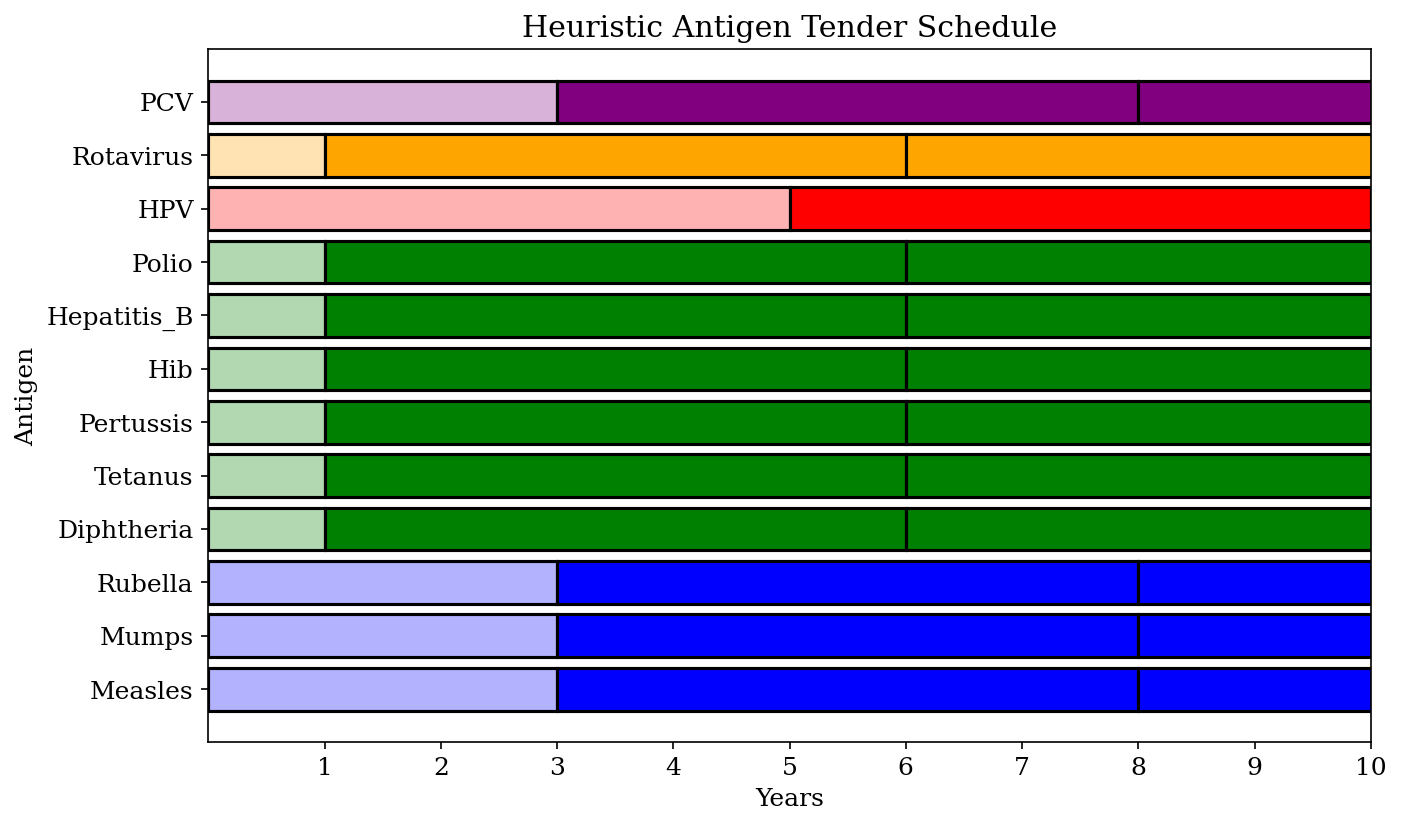

In [7]:
# Full script combining the color formatting and the black outline updates

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

df = tender_schedules_MCV

# Define color groups
colors = {
    "MMR Antigens": "blue",
    "MMR":"grey",
    "Hexa Antigens": "green",
    "Penta":"brown",
    "HPV": "red",
    "PCV": "purple",
    "Rota": "orange",
}

color_groups = {
    "MMR Antigens": ["Measles", "Mumps", "Rubella"],
    "MMR" : ["MMR"],
    "Hexa Antigens": ["Diphtheria", "Tetanus", "Pertussis", "Hib", "Polio", "Hepatitis_B"],
    "Penta":["Penta"],
    "HPV": ["HPV"],
    "PCV": ["PCV"],
    "Rota": ["Rotavirus"],
}

# Creating a color mapping for each antigen
antigen_colors = {}
for group, antigen_list in color_groups.items():
    for antigen in antigen_list:
        antigen_colors[antigen] = colors[group]

df['Color'] = df['Antigen'].map(antigen_colors)

# Plot configuration
plt.rcParams.update(mpl.rcParamsDefault)
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 12,
        "font.weight": "normal",
        "figure.titlesize": "medium",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "savefig.dpi": 300,
        "figure.dpi": 150,
        "savefig.bbox": "tight",
    }
)

# Plot the horizontal bar chart with color formatting and black outlines for each segment
plt.figure(figsize=(10, 6))
for i, row in df.iterrows():
    color = row['Color']
    if row['Starting'] == 0:
        color = mpl.colors.to_rgba(color, 0.3)  # Darken by reducing transparency
    
    if row["Fill"] == 'Partial':
        hatch = '//'
    elif row['Fill'] == 'None':
        color = 'black'
        hatch = None
    else:
        hatch = None
    
    # Add black outlines for separate segments
    # plt.barh(row['Antigen'], row['Ending'] - row['Starting'], left=row['Starting'], 
    #          color=color, edgecolor='black', linewidth=1.5, hatch=hatch)


    # Plot the bar with the corresponding properties
    plt.barh(row['Antigen'], row['Ending'] - row['Starting'], 
             left=row['Starting'], color=color, edgecolor='black', 
             linewidth=1.5, hatch=hatch)

    

plt.xlim(0, 10) 
plt.xticks(list(range(1, 11)))
plt.xlabel('Years')
plt.ylabel('Antigen')
plt.title('Heuristic Antigen Tender Schedule')
# plt.grid(True)
plt.savefig('heuristic_variable_length_reverse.pdf', bbox_inches='tight', pad_inches=0.1, dpi=600)
plt.show()


In [8]:
capacity_data[capacity_data.select_dtypes(include=['number']).columns] = capacity_data.select_dtypes(include=['number']).astype('int64')
capacity_data.iloc[:, :11]

,Manufacturer,1,2,3,4,5,6,7,8,9,10
0,AJ_Vaccines,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003,7711003
1,BB_NCIPD,39223956,46035056,46047056,39223956,39223956,39223956,42203556,42242956,42281156,42313356
2,Bharat_Biotech,61029105,61029105,61029105,61029105,0,0,0,0,0,0
3,Bilthoven,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153,12048153
4,Biological_E,164885690,0,0,171721890,167778390,167822490,164885690,164885690,164885690,164885690
5,China_National,12812242,0,0,0,0,0,0,0,0,0
6,GSK,226762686,226762686,226762686,226762686,226762686,234475434,226762686,226762686,226762686,226762686
7,Haffkine_Bio,80972855,0,0,0,0,0,0,0,0,0
8,LG_Chem,43702188,0,0,0,0,0,0,0,0,0
9,Merck_Sharp,56991052,56991052,56991052,56991052,56991052,0,86415810,86547210,77909310,79217310


In [9]:
uncovered_demand_DF

,antigen,1
0,Diphtheria,0.0
2,HPV,0.0
4,Hepatitis_B,0.0
6,Hib,0.0
8,Polio,0.0
10,Measles,0.0
12,Mumps,0.0
14,PCV,0.0
16,Pertussis,0.0
18,Rotavirus,0.0
